In [1]:
import numpy as np
import os
import torch
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
from accelerate import Accelerator
from torch_ema import ExponentialMovingAverage as EMA
from torchvision import transforms as tf
import torch.distributed as dist

from wavediffusion.plain_unet import plainUnet, masked_training_loop_plain, evaluate_plain
from wavediffusion.wavedata import npyDataResized
# from wavediffusion.waveutils import evaluate, sample_and_save

%load_ext autoreload
%autoreload 2

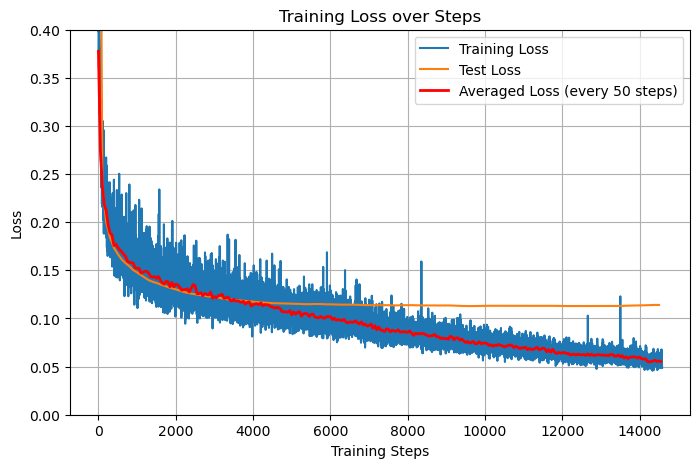

In [2]:
### Read in loss log and plot
path = "../../data/plain1/"
from matplotlib import pyplot as plt
import numpy as np
losses = []
steps = []
with open(path + "loss_log.txt", "r") as log_file:
    for line in log_file:
        line = line.strip()
        # if not line:          # skip empty lines
        #     continue
        step_str, loss_str = line.split(",")
        steps.append(int(step_str.strip()))
        losses.append(float(loss_str.strip()))

test_losses = []
test_steps = []
with open(path + "test_loss_log.txt", "r") as log_file:
    for line in log_file:
        line = line.strip()
        # if not line:          # skip empty lines
        #     continue
        step_str, loss_str = line.split(",")
        test_steps.append(int(step_str.strip()))
        test_losses.append(float(loss_str.strip()))

    
plt.figure(figsize=(8,5))
plt.plot(steps, losses, label='Training Loss')
plt.plot(test_steps, test_losses, label='Test Loss')
# Plot averaged loss every 50 steps
avg_losses = [np.mean(losses[i:i+50]) for i in range(0, len(losses), 50)]
plt.plot(range(0, len(losses), 50), avg_losses, color='red', linewidth=2, label='Averaged Loss (every 50 steps)')
plt.xlabel('Training Steps')
plt.ylabel('Loss')
plt.title('Training Loss over Steps')
plt.legend()
plt.ylim([0,0.4])
plt.grid()

In [3]:
train_batch_size=4
sample_batch_size=2
epochs=2
RESUME=False
path='/global/homes/j/jiarongw/scratch_folder/log1p/plain1/'
eval_everyn_step=100

In [4]:
train_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/train_global/'
train_file_names = [
    *( (f'wave_2010{i:02d}', f'forcing_2010{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2011{i:02d}', f'forcing_2011{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2012{i:02d}', f'forcing_2012{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2013{i:02d}', f'forcing_2013{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2014{i:02d}', f'forcing_2014{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2015{i:02d}', f'forcing_2015{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2016{i:02d}', f'forcing_2016{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2017{i:02d}', f'forcing_2017{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2018{i:02d}', f'forcing_2018{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2019{i:02d}', f'forcing_2019{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2020{i:02d}', f'forcing_2020{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2021{i:02d}', f'forcing_2021{i:02d}') for i in range(1, 13) ),
    *( (f'wave_2022{i:02d}', f'forcing_2022{i:02d}') for i in range(1, 13) ),
]
train_file_list = [(os.path.join(train_file_path, f'{x}.npy'), 
                    os.path.join(train_file_path, f'{f}.npy')) for x, f in train_file_names]   
stats_file = os.path.join(train_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
train = npyDataResized(
    train_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(train_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)
test_file_path = '/global/homes/j/jiarongw/scratch_folder/wave_data/test_global/'
test_file_names = [('wave_200804', 'forcing_200804')]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                    os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)

loader = DataLoader(train, batch_size=train_batch_size, shuffle=True)
loader_test = DataLoader(test, batch_size=sample_batch_size, shuffle=True)  # Used for generating samples during training  

In [5]:
model = plainUnet(in_dim=320, in_ch=3, out_ch=4, ch=256, 
                  ch_mult=(1, 2, 2), attn_resolutions=(16,))   

In [16]:
print(torch.cuda.is_available())
a = Accelerator(mixed_precision="fp16") 
print(a.state)

True
Distributed environment: DistributedType.NO
Num processes: 1
Process index: 0
Local process index: 0
Device: cuda

Mixed precision type: fp16



In [ ]:
# Train
log_file = open(path + "loss_log.txt", "w")
test_log_file = open(path + "test_loss_log.txt", "w")
ema = EMA(model.parameters(), decay=0.999)
start_epoch = 0

if RESUME and weights_file is not None:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])
    start_epoch = ckpt["epoch"]   # I can pass those to the training loop to count for epochs better
    # start_step = ckpt.get("step", 0)   # Same with steps
    # if a.is_main_process:
    #     print(f"Resuming from epoch {start_epoch}, step {start_step}")
          
ema.to(a.device)

train_iter = masked_training_loop_plain(loader, model, lr=1e-4, epochs=epochs, 
                                        accelerator=a, start_epoch=start_epoch)

last_epoch = -1

for ns in train_iter:
    # ---- logging (only main process) ----
    if a.is_main_process:
        log_file.write(f"{ns.step}, {ns.loss.item():.6f}\n")
        log_file.flush()
        ns.pbar.set_description(f"Loss={ns.loss.item():.5f}")        
        
    ema.update()

    # ---- evaluation ----
    if ns.step % eval_everyn_step == 0:
        a.wait_for_everyone()
        if a.is_main_process:     
            print('Evaluating... at step ', ns.step)
            val_loss = evaluate_plain(model, ema, loader_test, a) # Compute on all GPUs but gather
            test_log_file.write(f"{ns.step}, {val_loss.item():.6f}\n")
            test_log_file.flush()
        a.wait_for_everyone()

  0%|          | 0/2 [00:00<?, ?it/s]

Evaluating... at step  0


### Evaluate

In [2]:
test_file_path = '../../data/test_global/'
test_file_names = [
    *( (f'wave_2008{i:02d}', f'forcing_2008{i:02d}') for i in range(4, 5) ),
]
test_file_list = [(os.path.join(test_file_path, f'{x}.npy'), 
                    os.path.join(test_file_path, f'{f}.npy')) for x, f in test_file_names]   
stats_file = os.path.join(test_file_path, 'stats.npz')
stats = np.load(stats_file)
meanx, stdx = stats['meanx'], stats['stdx']
meanf, stdf = stats['meanf'], stats['stdf']
test = npyDataResized(
    test_file_list,
    resize_x=(320,320), resize_f=(320,320), 
    landmaskname=os.path.join(test_file_path, 'mask.npy'),
    use_icymask=True, compute_stats=False,
    meanx=meanx, stdx=stdx, meanf=meanf, stdf=stdf,
    OPTION=1
)
loader_test = DataLoader(test, batch_size=1, shuffle=True)  # Used for generating samples during training  

In [19]:
path = '../../data/plain1/'
weights_file = path + 'ckpt_6.pt'
RESUME = True

a = Accelerator(cpu=True) 
model = plainUnet(in_dim=320, in_ch=3, out_ch=4, ch=256, 
                  ch_mult=(1, 2, 2), attn_resolutions=(16,))   
ema = EMA(model.parameters(), decay=0.999)

ema, model, loader_test = a.prepare(ema, model, loader_test)

if RESUME and weights_file is not None:
    ckpt = torch.load(weights_file, map_location="cpu")
    model.load_state_dict(ckpt["model"])
    ema.load_state_dict(ckpt["ema"])

/var/folders/vj/y2ddzy2n2g9gz_0z019p14v80000gn/T/ipykernel_621/361299947.py:13: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  ckpt = torch.load(weights_file, map_location="c

In [20]:
# loader_iter = iter(loader_test) 
# x, f, mask = next(loader_iter)
# Manually pick the frame to visualize
x, f, mask = test.__getitem__(0)
x = x.unsqueeze(0); f = f.unsqueeze(0); mask = mask.unsqueeze(0)
with torch.no_grad():
    with ema.average_parameters():
        y = model(f)
        x_ = test.invert_x(y[0])
        x_pred = x_ * tf.Resize((320,720))(mask[0])
    x_truth = test.invert_x(x[0]) * tf.Resize((320,720))(mask[0])

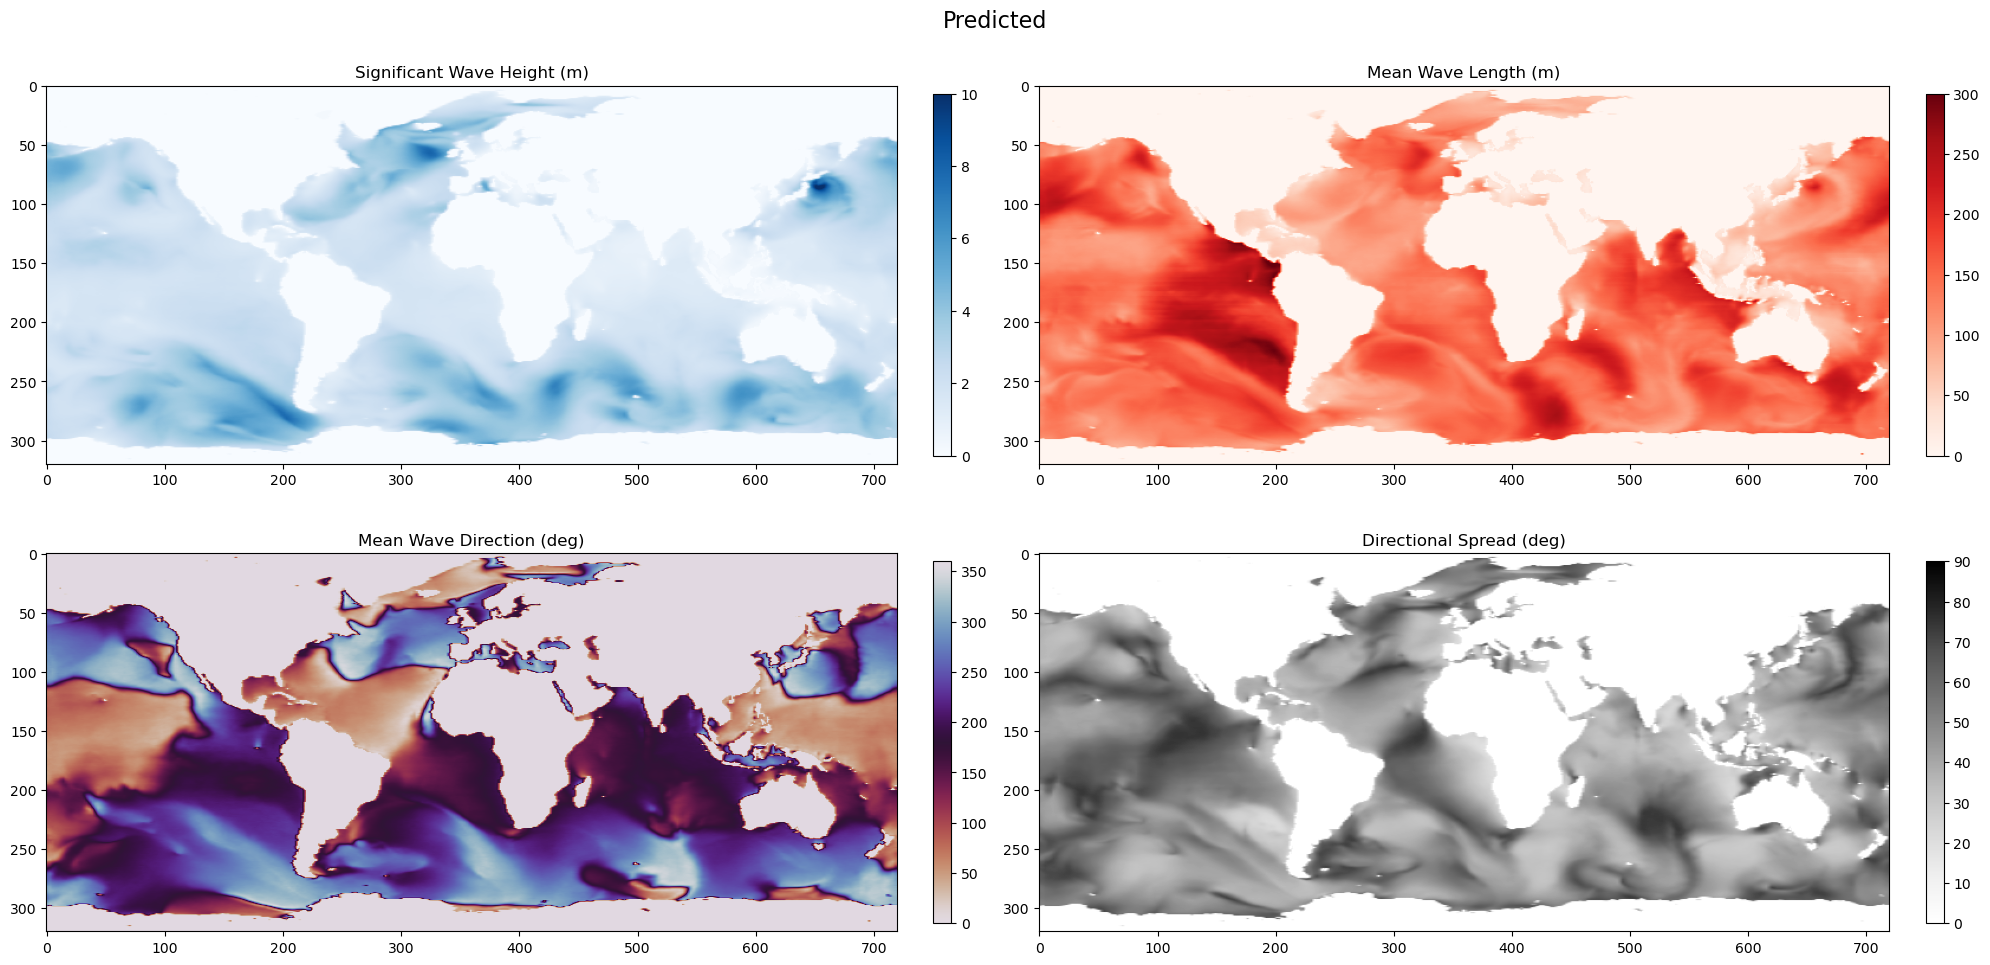

In [21]:
from torchvision import transforms as tf
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(x_pred.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(x_pred.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
img2 = axes[1,0].imshow(x_pred.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
img3 = axes[1,1].imshow(x_pred.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

plt.suptitle('Predicted', fontsize=16)
plt.tight_layout()
plt.show()

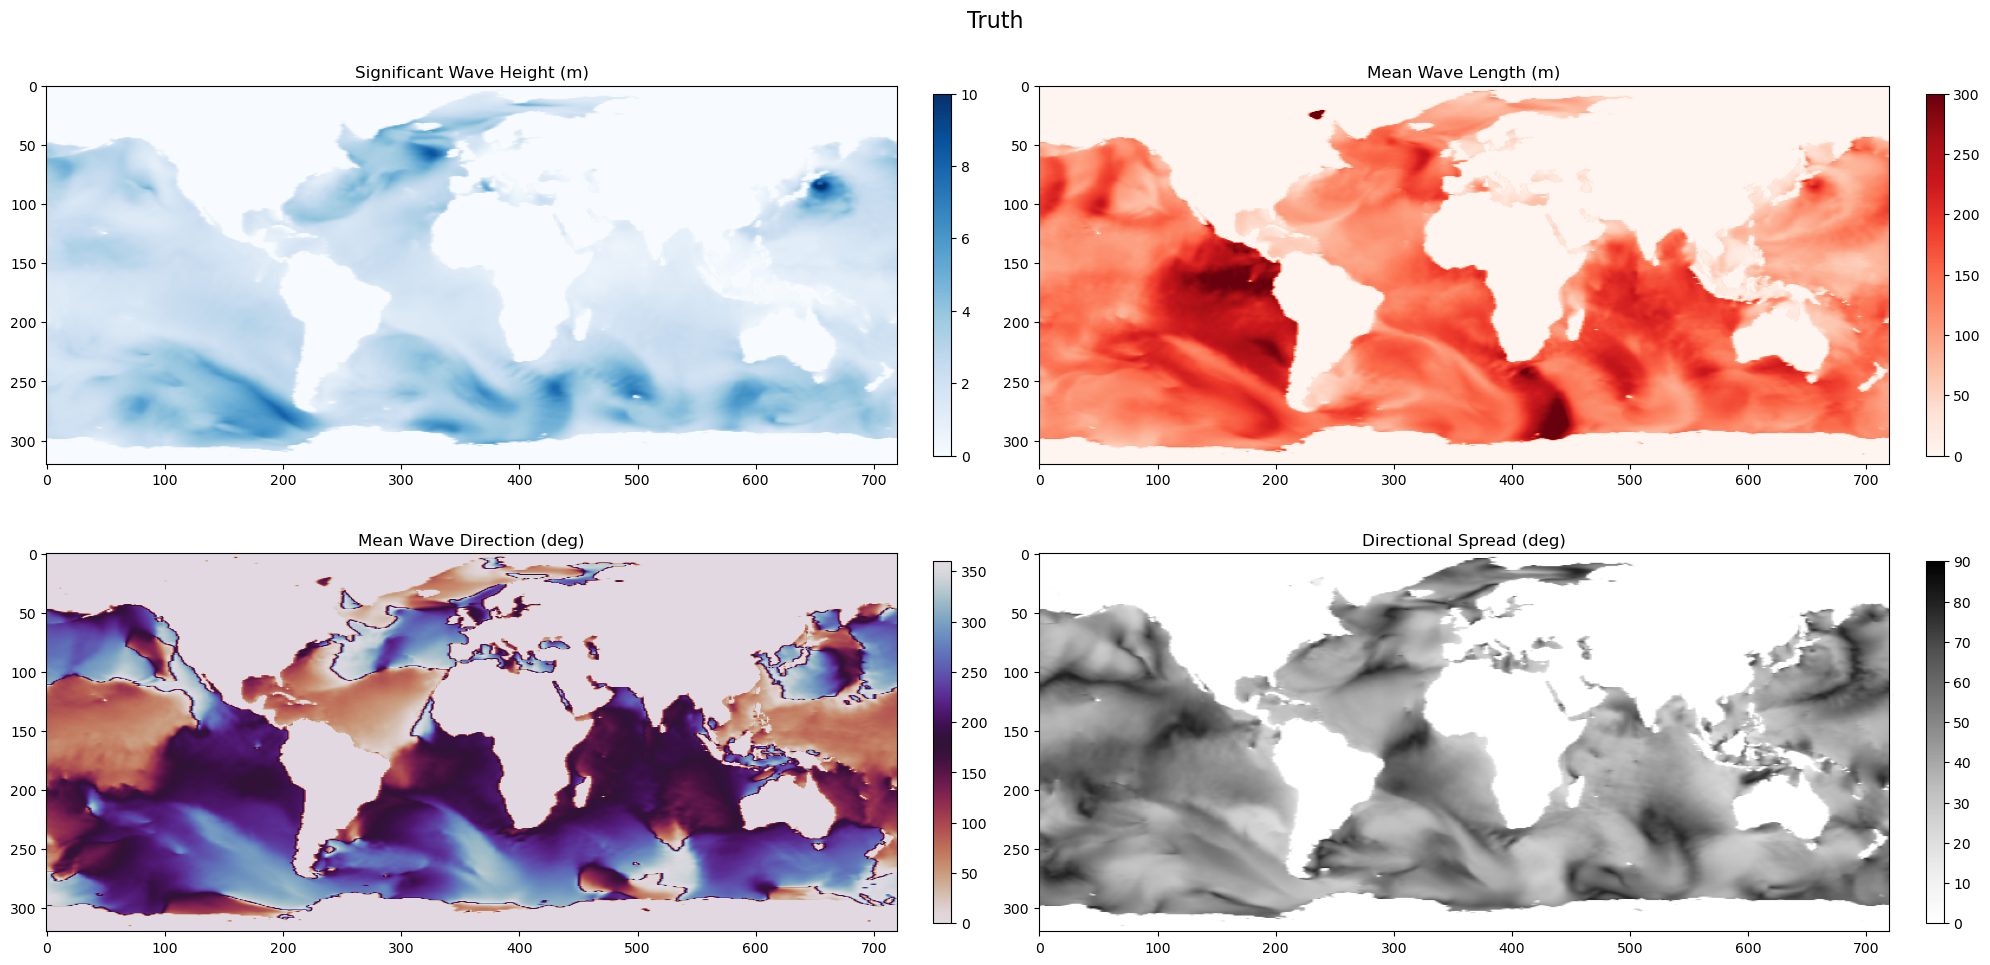

In [18]:
from torchvision import transforms as tf
fig, axes = plt.subplots(2, 2, figsize=(20, 10))
img0 = axes[0,0].imshow(x_truth.cpu().numpy()[0,::-1], vmin=0, vmax=10, cmap='Blues')
img1 = axes[0,1].imshow(x_truth.cpu().numpy()[1,::-1], vmin=0, vmax=300, cmap='Reds')
img2 = axes[1,0].imshow(x_truth.cpu().numpy()[2,::-1], vmin=0, vmax=360, cmap='twilight_r')
img3 = axes[1,1].imshow(x_truth.cpu().numpy()[3,::-1], vmin=0, vmax=90, cmap='Greys')
plt.colorbar(img0, ax=axes[0,0], fraction=0.02, pad=0.04)
plt.colorbar(img1, ax=axes[0,1], fraction=0.02, pad=0.04)
plt.colorbar(img2, ax=axes[1,0], fraction=0.02, pad=0.04)
plt.colorbar(img3, ax=axes[1,1], fraction=0.02, pad=0.04)
axes[0,0].set_title('Significant Wave Height (m)')
axes[0,1].set_title('Mean Wave Length (m)')
axes[1,0].set_title('Mean Wave Direction (deg)')
axes[1,1].set_title('Directional Spread (deg)')

plt.suptitle('Truth', fontsize=16)
plt.tight_layout()
plt.show()